# 期交所 TXO → 7 天 / 14 天 VIX：驗證報告

資料源：期交所「選擇權每日交易行情」公開資料（免帳號、免 Shioaji 連線）

## 方法

1. 逐到期日算 variance swap：$\sigma_T^2 = \frac{2}{T}\sum_i \frac{\Delta K_i}{K_i^2}e^{rT}Q(K_i) - \frac{1}{T}\left(\frac{F}{K_0}-1\right)^2$
2. 固定天期插值到 N 天：$\sigma_N^2 = \left[T_1\sigma_1^2\frac{d_2-N}{d_2-d_1} + T_2\sigma_2^2\frac{N-d_1}{d_2-d_1}\right]\frac{365}{N}$，$VIX_N = 100\sqrt{\sigma_N^2}$
3. $Q(K)$：買賣中價優先，**但要過品質閘門**（相對價差 ≤ 30%、與結算價偏離 ≤ 30%），不過關就回退結算價
4. $T$ = 整日數 / 365；$r$ = 0（7~14 天 $e^{rT}$ 影響 < 0.05%）
5. 候選到期日 = 週三週選 + 週五週選 + 月選，全部納入（`dte ≥ 1`）

> **為什麼要品質閘門**：EOD 的「最後最佳買價/賣價」對冷門履約價常是隔很久的殘留報價，
> 實測 2026/07/31 出現 bid 0.5 / ask 363（中價是結算價的 13 倍）。不濾掉的話對照官方 VIX
> 的 MAE 會從 0.29 惡化到 1.02。

In [1]:
import os, sys, glob
sys.path.insert(0, r"C:\Users\Alrami\Finance_py\claude_strats")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from taifex_vix import config, fetch, pipeline

mpl.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "Microsoft YaHei", "DejaVu Sans"]
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["figure.figsize"] = (13, 4.2)
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.3
pd.set_option("display.width", 200)

df = pipeline.load_output()
df["trade_date"] = pd.to_datetime(df["trade_date"])
df = df.sort_values("trade_date").reset_index(drop=True)
print(f"主輸出 {len(df)} 個交易日：{df.trade_date.min():%Y-%m-%d} ~ {df.trade_date.max():%Y-%m-%d}")
df.tail(5)[["trade_date", "vix7", "vix14", "vix30", "vix7_mode", "vix14_mode", "ba_ratio", "strip_min"]]

主輸出 1598 個交易日：2020-01-02 ~ 2026-08-03


,trade_date,vix7,vix14,vix30,vix7_mode,vix14_mode,ba_ratio,strip_min
1593,2026-07-28,40.934075,40.081038,39.990557,interp,interp,0.139537,142.0
1594,2026-07-29,46.628425,43.727038,41.878212,exact,exact,0.139125,110.0
1595,2026-07-30,49.896454,46.232086,44.384793,interp,interp,0.079271,140.0
1596,2026-07-31,41.330152,35.089597,39.866681,exact,exact,0.082742,106.0
1597,2026-08-03,42.240066,41.094445,39.181981,interp,interp,0.102648,174.0


## 1. 資料覆蓋與插值模式

`exact` = 當天剛好有 N 天到期的序列（週五收盤時 F 系列會正好落在 7/14 天）；`interp` = 內插；`no_bracket` = 夾不住，輸出 NaN。

In [2]:
print("=== 插值模式分布 ===")
for N in (7, 14, 30):
    vc = df[f"vix{N}_mode"].value_counts(dropna=False)
    nan_n = df[f"vix{N}"].isna().sum()
    print(f"VIX{N:>2}: " + "  ".join(f"{k}={v}" for k, v in vc.items()) + f"   | NaN {nan_n}")

print("\n=== 到期日來源（哪一層解出到期日）===")
print(df["expiry_src"].value_counts(dropna=False).to_string())

print("\n=== 基本統計 ===")
print(df[["vix7", "vix14", "vix30", "ba_ratio", "strip_min", "n_expiry_used"]]
      .describe(percentiles=[.05, .25, .5, .75, .95]).to_string())

bad = df[df["vix7"].isna() | df["vix14"].isna()]
print(f"\n=== VIX7/14 算不出來的日子：{len(bad)} 天 ===")
if len(bad):
    print(bad[["trade_date", "vix7_mode", "vix14_mode", "n_expiry_used", "warnings"]].to_string(index=False))

=== 插值模式分布 ===
VIX 7: interp=1202  exact=367  no_bracket=20  extrap=9   | NaN 20
VIX14: interp=1329  exact=263  no_bracket=4  extrap=2   | NaN 4
VIX30: interp=1524  exact=74   | NaN 0

=== 到期日來源（哪一層解出到期日）===
empirical        1340
col               156
fsp                89
empirical,fsp      13

=== 基本統計 ===
              vix7        vix14        vix30     ba_ratio    strip_min  n_expiry_used
count  1578.000000  1594.000000  1598.000000  1598.000000  1598.000000    1598.000000
mean     20.903569    21.320956    21.795195     0.465804    60.729036       6.467459
std       7.377783     6.749359     6.482776     0.150556    22.803422       1.074497
min       9.541733     9.894350    12.141653     0.069403    21.000000       5.000000
5%       12.525708    13.318175    13.994459     0.180324    35.000000       5.000000
25%      15.961335    16.706701    17.381261     0.384678    47.000000       6.000000
50%      19.444360    20.111243    20.627995     0.472536    54.000000       6.000000
75

## 2. 天期結構：7 天與 14 天有沒有被夾住

畫出每天用來插值的 `d1`/`d2`。理想是緊貼目標天期；帶子愈寬代表當天可用序列愈稀疏，插值誤差愈大。

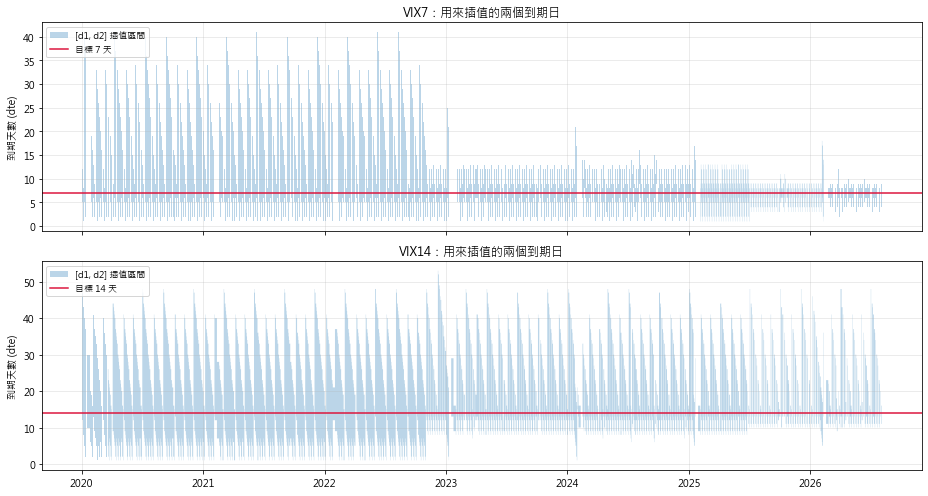

VIX7 插值區間寬度：中位數 7 天，90 分位 28 天，最大 35 天
VIX14 插值區間寬度：中位數 21 天，90 分位 33 天，最大 40 天


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, N in zip(axes, (7, 14)):
    ax.fill_between(df.trade_date, df[f"vix{N}_d1"], df[f"vix{N}_d2"],
                    alpha=0.3, step="mid", label=f"[d1, d2] 插值區間")
    ax.axhline(N, color="crimson", lw=1.5, label=f"目標 {N} 天")
    ax.set_ylabel("到期天數 (dte)")
    ax.set_title(f"VIX{N}：用來插值的兩個到期日")
    ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

for N in (7, 14):
    w = (df[f"vix{N}_d2"] - df[f"vix{N}_d1"]).dropna()
    print(f"VIX{N} 插值區間寬度：中位數 {w.median():.0f} 天，90 分位 {w.quantile(.9):.0f} 天，最大 {w.max():.0f} 天")

## 3. VIX 時間序列

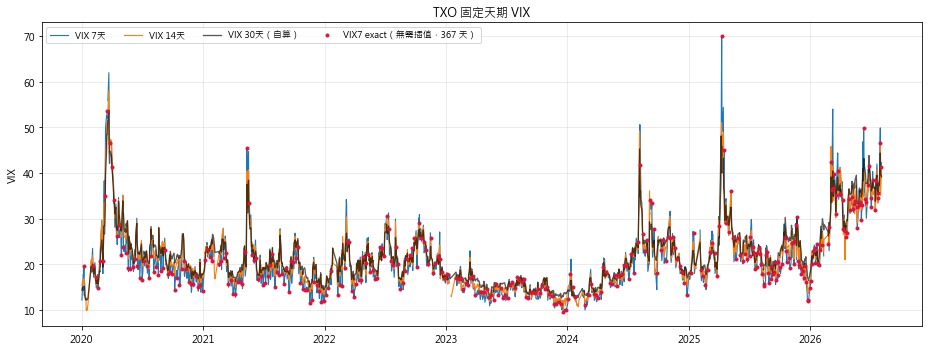

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df.trade_date, df.vix7, lw=1.1, label="VIX 7天")
ax.plot(df.trade_date, df.vix14, lw=1.1, label="VIX 14天")
ax.plot(df.trade_date, df.vix30, lw=1.3, color="k", alpha=0.65, label="VIX 30天（自算）")
ex = df[df.vix7_mode == "exact"]
ax.scatter(ex.trade_date, ex.vix7, s=9, color="crimson", zorder=5,
           label=f"VIX7 exact（無需插值，{len(ex)} 天）")
ax.set_ylabel("VIX"); ax.set_title("TXO 固定天期 VIX")
ax.legend(ncol=4, fontsize=9); plt.tight_layout(); plt.show()

## 4. 引擎驗證：自算 30 天 VIX vs 期交所官方收盤 VIX

這是整條 pipeline 唯一的外部真值檢查。官方 VIX 也是 30 天、也是 CBOE 公式，
所以自算的 VIX30 應該要貼得很近；貼得近就代表 strip / F / K0 / T / 插值都對，
7 天與 14 天才可信。

> 期交所只提供**最近 3 個月**的每日收盤 VIX。`load_official_vix_all()` 會把每次抓到的
> 月檔存進 `meta/`，所以定期執行就會慢慢累積出長期對照序列。

可比對區間：64 個交易日（2026-05-04 ~ 2026-08-03）

平均差 -0.246   MAE 0.296   RMSE 0.499   相關 0.9857   最大絕對差 2.599


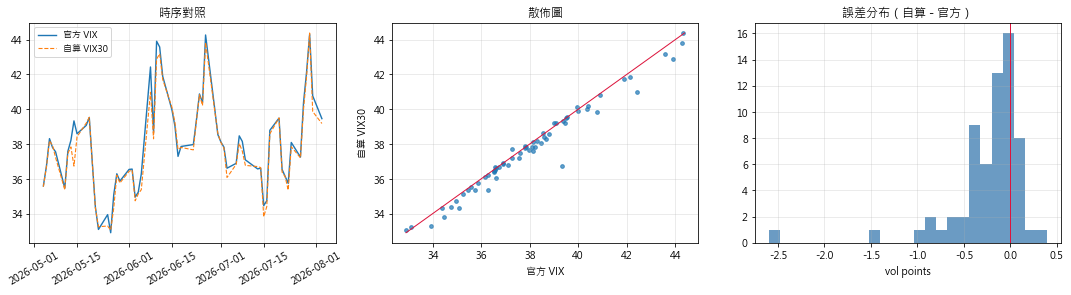


誤差最大的 5 天：
trade_date  official_vix     vix30      diff  vix30_d1  vix30_d2  ba_ratio  strip_min
2026-05-14         39.33 36.730879 -2.599121      13.0      34.0  0.155286      121.0
2026-06-08         42.43 40.979730 -1.450270      14.0      37.0  0.185671      132.0
2026-06-10         43.91 42.885264 -1.024736      14.0      35.0  0.223354      117.0
2026-06-05         36.28 35.376224 -0.903776      17.0      40.0  0.078261      120.0
2026-07-31         40.77 39.866681 -0.903319      19.0      47.0  0.082742      106.0


In [5]:
off = fetch.load_official_vix_all()
m = df.merge(off, on="trade_date", how="inner")
print(f"可比對區間：{len(m)} 個交易日"
      + (f"（{m.trade_date.min():%Y-%m-%d} ~ {m.trade_date.max():%Y-%m-%d}）" if len(m) else ""))

if len(m):
    diff = m.vix30 - m.official_vix
    print(f"\n平均差 {diff.mean():+.3f}   MAE {diff.abs().mean():.3f}   "
          f"RMSE {np.sqrt((diff**2).mean()):.3f}   相關 {m.vix30.corr(m.official_vix):.4f}   "
          f"最大絕對差 {diff.abs().max():.3f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    axes[0].plot(m.trade_date, m.official_vix, lw=1.4, label="官方 VIX")
    axes[0].plot(m.trade_date, m.vix30, lw=1.1, ls="--", label="自算 VIX30")
    axes[0].set_title("時序對照"); axes[0].legend(fontsize=9)
    axes[0].tick_params(axis="x", rotation=30)

    lo, hi = m[["vix30", "official_vix"]].min().min(), m[["vix30", "official_vix"]].max().max()
    axes[1].scatter(m.official_vix, m.vix30, s=14, alpha=0.7)
    axes[1].plot([lo, hi], [lo, hi], color="crimson", lw=1)
    axes[1].set_xlabel("官方 VIX"); axes[1].set_ylabel("自算 VIX30"); axes[1].set_title("散佈圖")

    axes[2].hist(diff, bins=25, color="steelblue", alpha=0.8)
    axes[2].axvline(0, color="crimson", lw=1)
    axes[2].set_title(f"誤差分布（自算 - 官方）"); axes[2].set_xlabel("vol points")
    plt.tight_layout(); plt.show()

    worst = m.assign(diff=diff).reindex(diff.abs().sort_values(ascending=False).index).head(5)
    print("\n誤差最大的 5 天：")
    print(worst[["trade_date", "official_vix", "vix30", "diff", "vix30_d1", "vix30_d2",
                 "ba_ratio", "strip_min"]].to_string(index=False))
else:
    print("沒有重疊區間 —— 官方只提供最近 3 個月，請確認回補區間有涵蓋到。")

## 5. 資料品質

- `ba_ratio`：strip 中真正採用「買賣中價」的比例。剩下的是被品質閘門擋下、改用結算價的。
  這個值偏低是**正常**的 —— EOD 殘留報價品質差，濾掉才對得上官方。
- `strip_min`：當天用到的到期日裡最少的 strip 檔數，太少代表報價稀疏。

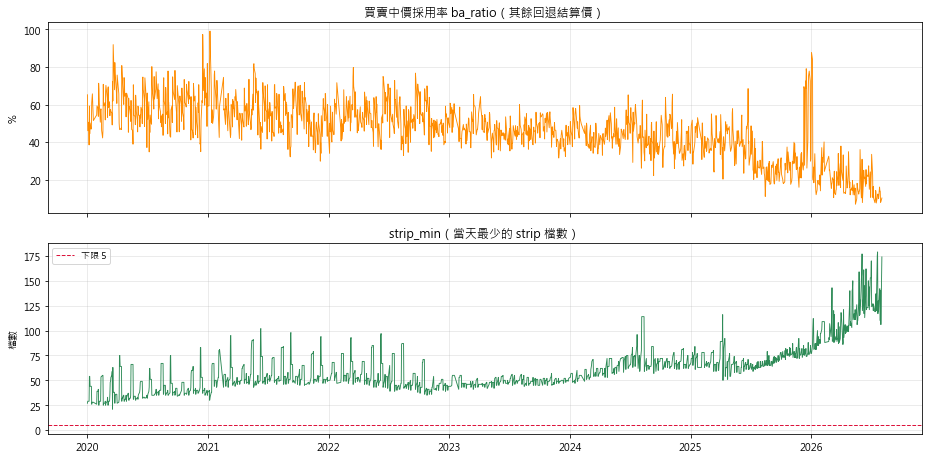

ba_ratio  中位數 47.3%   5 分位 18.0%
strip_min 中位數 54   最小 21

有 warning 的交易日：396 / 1598
trade_date                 warnings
2026-07-08   202607W2(d0):dte=0 < 1
2026-07-13 202607F2(d-3):dte=-3 < 1
2026-07-15     202607(d0):dte=0 < 1
2026-07-17   202607F3(d0):dte=0 < 1
2026-07-22   202607W4(d0):dte=0 < 1
2026-07-24   202607F4(d0):dte=0 < 1
2026-07-29   202607W5(d0):dte=0 < 1
2026-07-31   202607F5(d0):dte=0 < 1


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
axes[0].plot(df.trade_date, df.ba_ratio * 100, lw=0.9, color="darkorange")
axes[0].set_ylabel("%"); axes[0].set_title("買賣中價採用率 ba_ratio（其餘回退結算價）")
axes[1].plot(df.trade_date, df.strip_min, lw=0.9, color="seagreen")
axes[1].axhline(config.MIN_STRIP_COUNT, color="crimson", lw=1, ls="--",
                label=f"下限 {config.MIN_STRIP_COUNT}")
axes[1].set_ylabel("檔數"); axes[1].set_title("strip_min（當天最少的 strip 檔數）")
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"ba_ratio  中位數 {df.ba_ratio.median():.1%}   5 分位 {df.ba_ratio.quantile(.05):.1%}")
print(f"strip_min 中位數 {df.strip_min.median():.0f}   最小 {df.strip_min.min():.0f}")

wn = df[df.warnings.notna()]
print(f"\n有 warning 的交易日：{len(wn)} / {len(df)}")
if len(wn):
    print(wn[["trade_date", "warnings"]].tail(8).to_string(index=False))

## 6. 期限結構

正常盤（contango）短天期 < 長天期；恐慌時短天期會衝上去造成倒掛。
`vix7 - vix14` 拿來當恐慌 / 均值回歸訊號的原料。

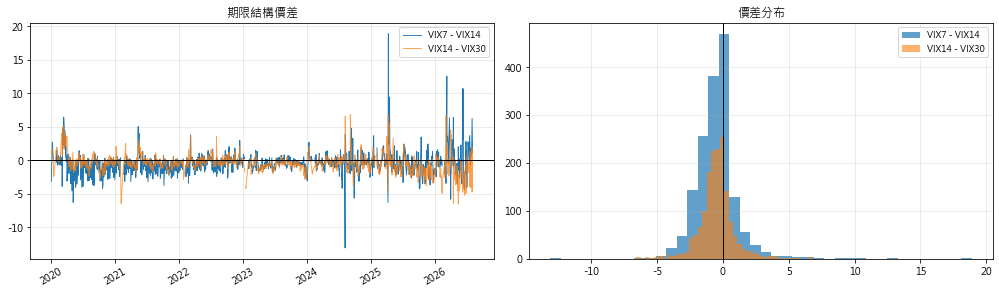

VIX7 - VIX14 ：均值 -0.49  中位 -0.47  倒掛(>0)佔比 30.0%
VIX14 - VIX30：均值 -0.46  中位 -0.46  倒掛(>0)佔比 29.2%


In [7]:
df["sp_7_14"] = df.vix7 - df.vix14
df["sp_14_30"] = df.vix14 - df.vix30

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].plot(df.trade_date, df.sp_7_14, lw=0.9, label="VIX7 - VIX14")
axes[0].plot(df.trade_date, df.sp_14_30, lw=0.9, alpha=0.75, label="VIX14 - VIX30")
axes[0].axhline(0, color="k", lw=1)
axes[0].set_title("期限結構價差"); axes[0].legend(fontsize=9)
axes[0].tick_params(axis="x", rotation=30)

axes[1].hist(df.sp_7_14.dropna(), bins=40, alpha=0.7, label="VIX7 - VIX14")
axes[1].hist(df.sp_14_30.dropna(), bins=40, alpha=0.6, label="VIX14 - VIX30")
axes[1].axvline(0, color="k", lw=1)
axes[1].set_title("價差分布"); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"VIX7 - VIX14 ：均值 {df.sp_7_14.mean():+.2f}  中位 {df.sp_7_14.median():+.2f}  "
      f"倒掛(>0)佔比 {(df.sp_7_14 > 0).mean():.1%}")
print(f"VIX14 - VIX30：均值 {df.sp_14_30.mean():+.2f}  中位 {df.sp_14_30.median():+.2f}  "
      f"倒掛(>0)佔比 {(df.sp_14_30 > 0).mean():.1%}")

## 7. 單日拆解（抽查用）

改 `PEEK` 就能看某一天各到期日的 F / K0 / strip / variance 明細。

=== 2026-08-03 各到期日 ===
expiry_code  dte expiry_source   ok        T       F      K0  strip_count  n_ba  n_settle  ba_ratio       vix  reason
   202608W1    2           col True 0.005479 43117.5 43100.0          211    72       139  0.341232 47.845099     NaN
   202608F1    4           col True 0.010959 43220.0 43200.0          211     6       205  0.028436 46.608310     NaN
   202608W2    9           col True 0.024658 43170.0 43150.0          174     0       174  0.000000 40.856177     NaN
   202608F2   11           col True 0.030137 43200.0 43200.0          174     2       172  0.011494 41.663561     NaN
     202608   16           col True 0.043836 43385.0 43300.0          212    28       184  0.132075 40.830949     NaN
     202609   44           col True 0.120548 43380.0 43300.0          277     8       269  0.028881 38.564879     NaN
     202610   79           col True 0.216438 43570.0 43500.0          187     1       186  0.005348 35.190689     NaN
     202612  135           col T

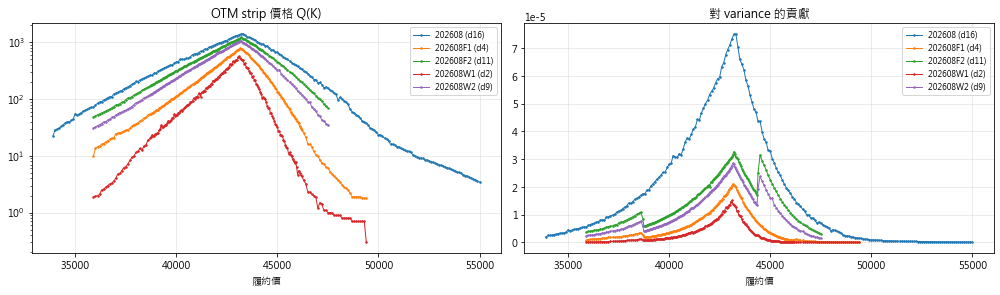

In [8]:
PEEK = df.trade_date.max().date()

detail = pd.read_csv(os.path.join(config.DETAIL_DIR, f"{PEEK:%Y%m%d}.csv"))
cols = ["expiry_code", "dte", "expiry_source", "ok", "T", "F", "K0",
        "strip_count", "n_ba", "n_settle", "ba_ratio", "vix", "reason"]
print(f"=== {PEEK} 各到期日 ===")
print(detail[cols].to_string(index=False))

strip_fp = os.path.join(config.DETAIL_DIR, f"{PEEK:%Y%m%d}_strip.csv")
if os.path.exists(strip_fp):
    strip = pd.read_csv(strip_fp)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
    for code, g in strip.groupby("expiry_code"):
        if g.dte.iloc[0] > 30:
            continue
        axes[0].semilogy(g.strike, g.Q, lw=1, marker=".", ms=3, label=f"{code} (d{g.dte.iloc[0]})")
        axes[1].plot(g.strike, g.contribution, lw=1, marker=".", ms=3, label=f"{code} (d{g.dte.iloc[0]})")
    axes[0].set_title("OTM strip 價格 Q(K)"); axes[0].set_xlabel("履約價"); axes[0].legend(fontsize=8)
    axes[1].set_title("對 variance 的貢獻"); axes[1].set_xlabel("履約價"); axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()